# 1. Výpočet tepové frekvence z EKG signálu

### Zadání
Ve zdrojové databázi najdete celkem 17 měření EKG signálu. Signál je již filtrován a centralizován kolem podélné osy. EKG signál obsahuje dominantní peaky, které se nazývají R vrcholy. Vzdálenost těchto vrcholů určuje dobu mezi jednotlivými tepy. Počet tepů za minutu je tedy počet R vrcholů v signálu o délce jedné minuty. Navrhněte algoritmus, který bude automaticky detekovat počet R vrcholů v EKG signálech a prezentujte tepovou frekvenci při jednotlivých jízdách/měřeních. Vás algoritmus následně otestujte na databázi MIT-BIH https://physionet.org/content/nsrdb/1.0.0/ a prezentujte jeho úspěšnost vzhledem k anotovaným datům z databáze.

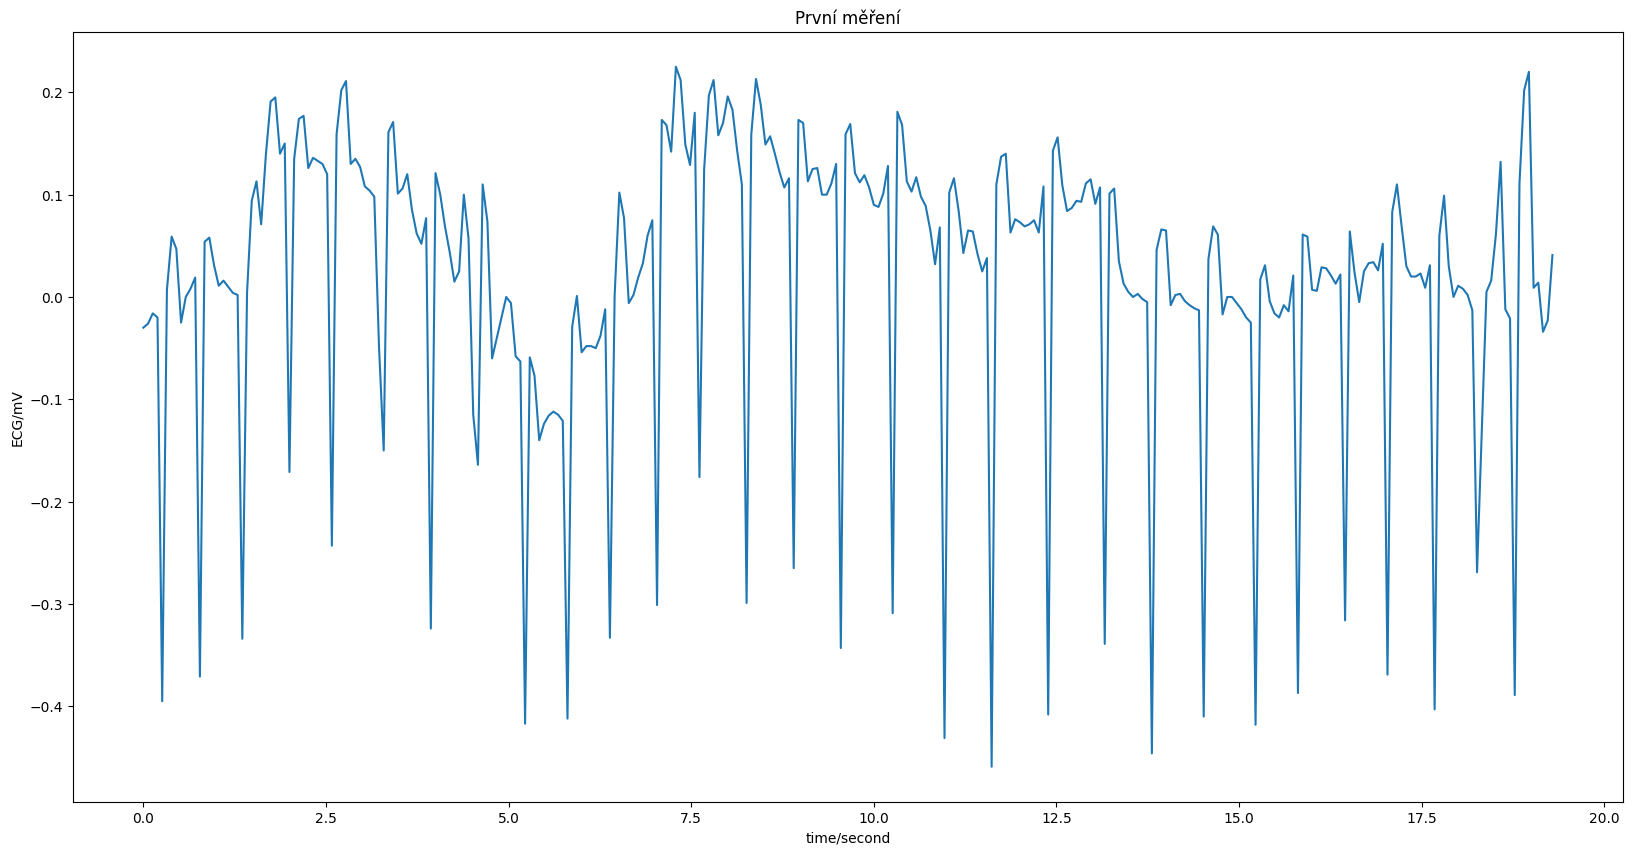

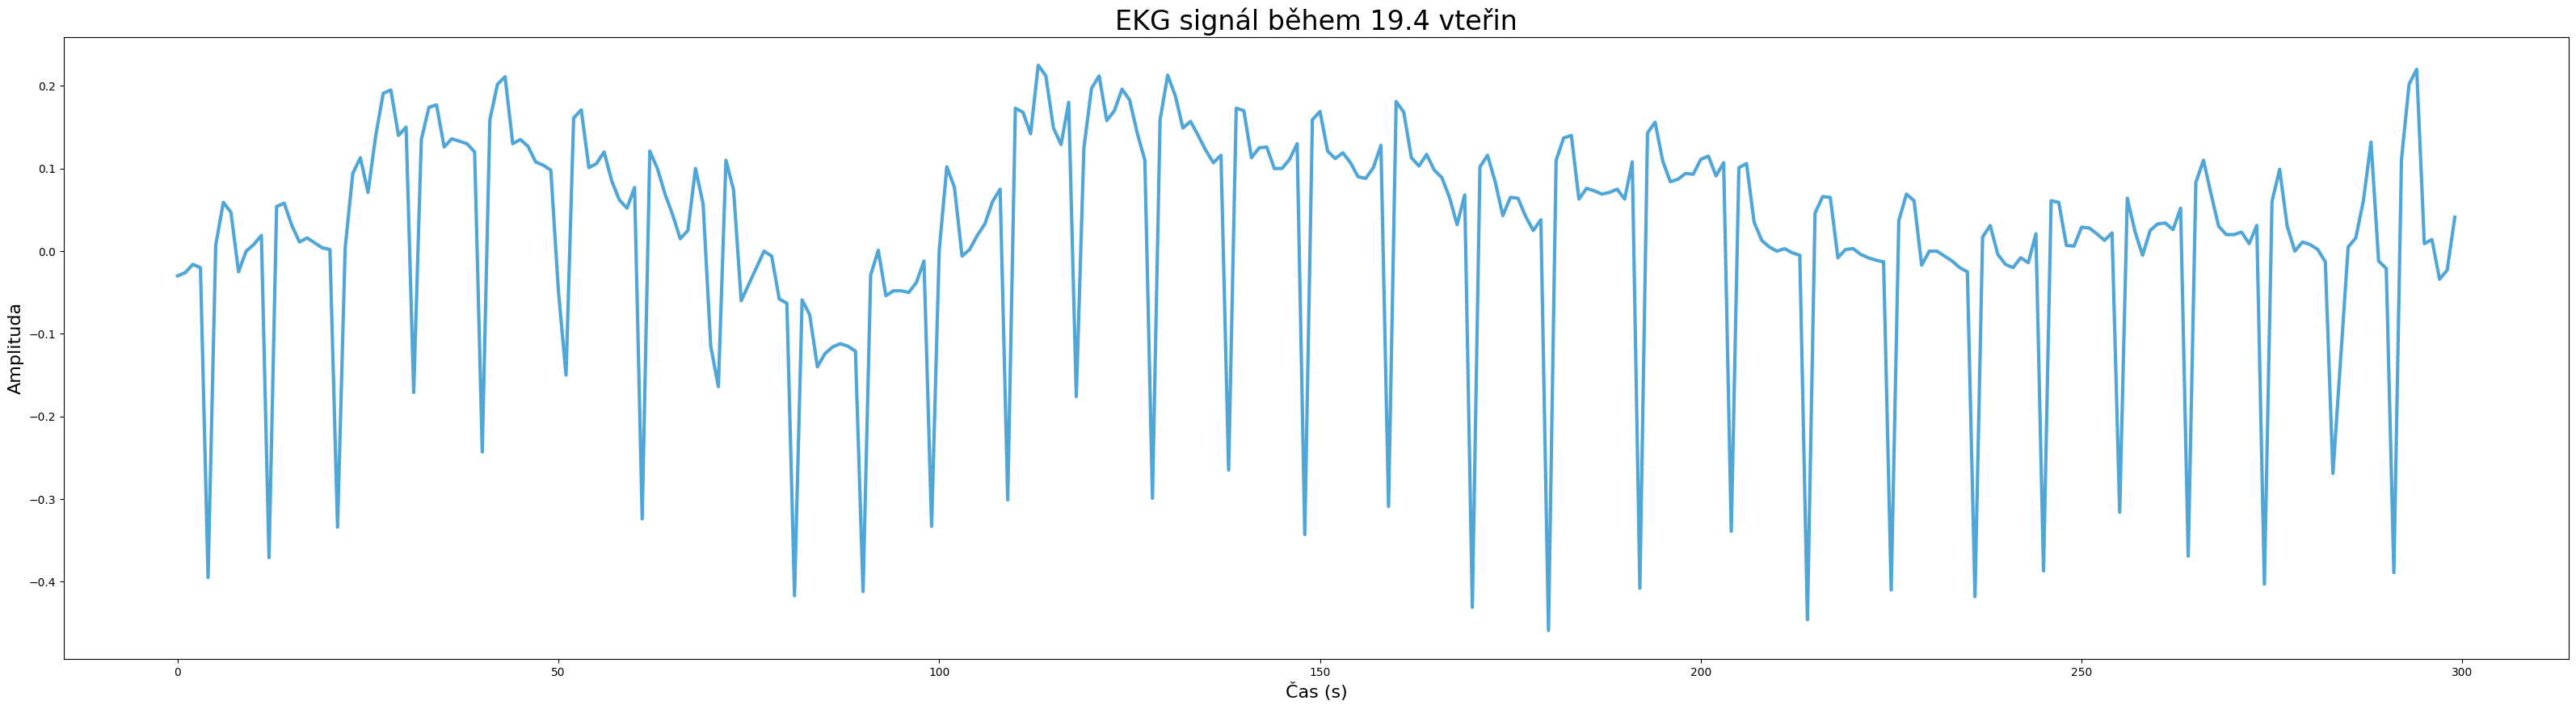

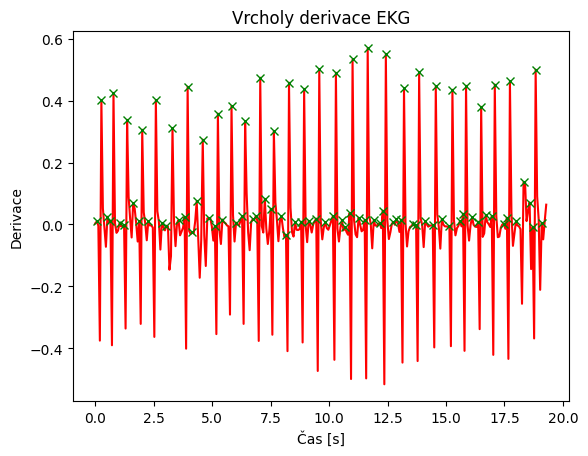

Tepová frekvence: 93.20147680508789
Počet R vln: 28


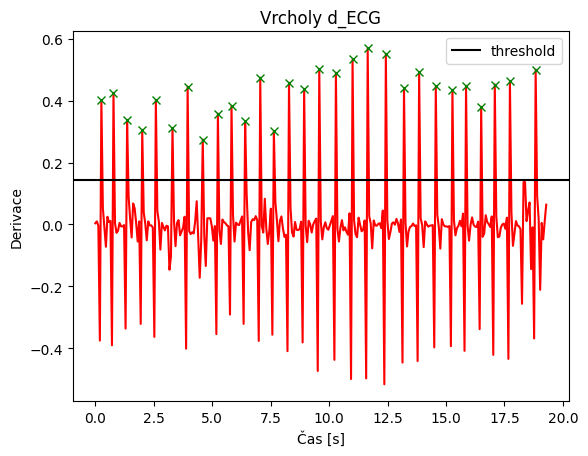

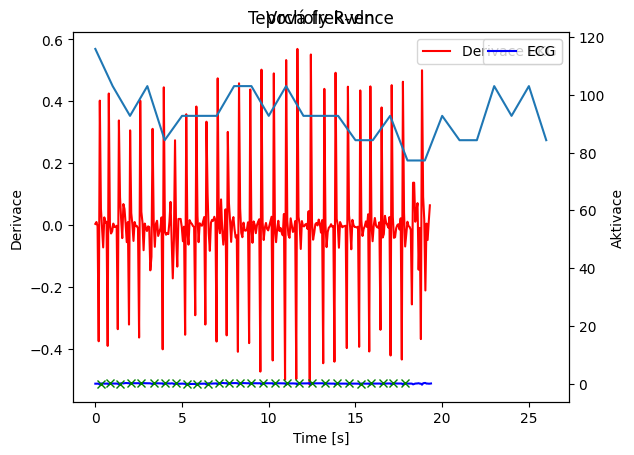

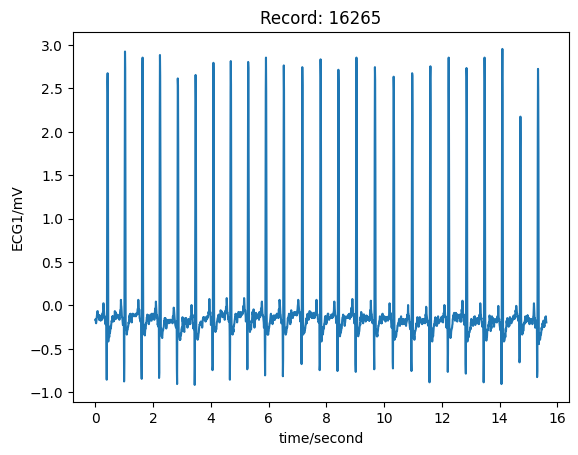

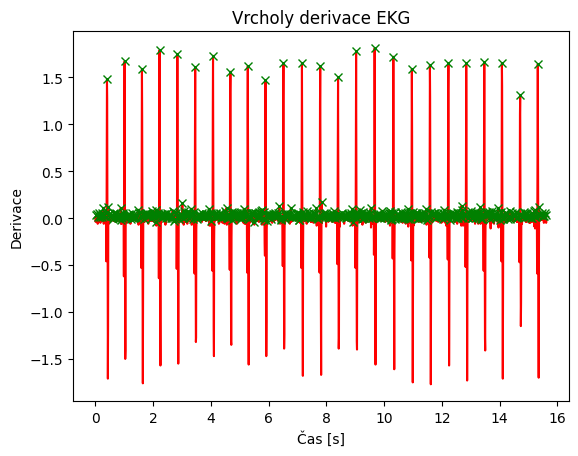

Průměrná tepová frekvence: 96.52103147638447
Rozptyl tepové frekvence: 4.303409157985766
Procento správně detekovaných R vrcholů: 0.0%


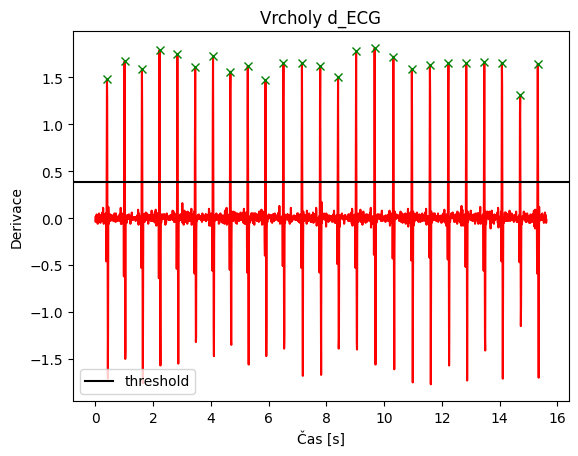

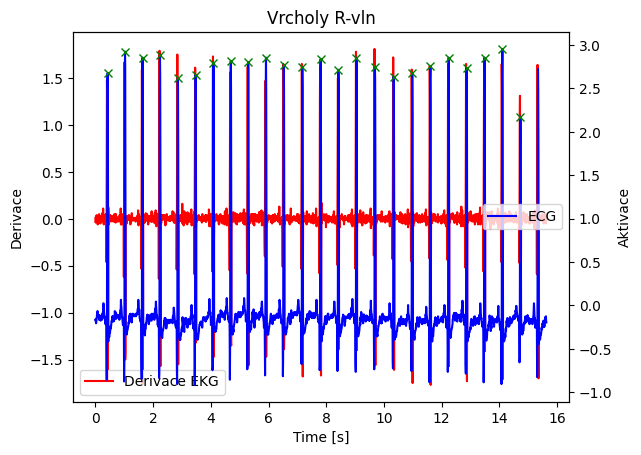

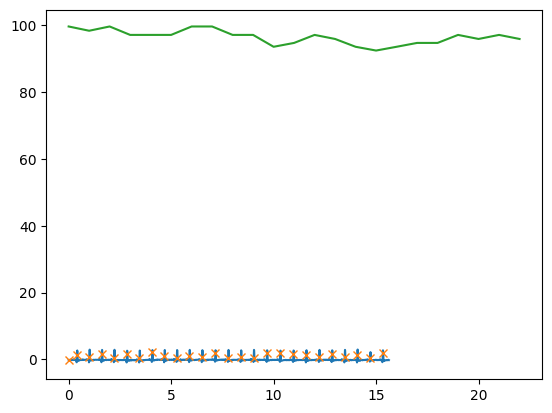

In [2]:
import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns

from scipy import signal as sps
from scipy.ndimage import label
from scipy.stats import zscore
from scipy.interpolate import interp1d
from scipy.integrate import trapz

# physionet data
import wfdb
from wfdb import processing

# otevření datasetu
record = wfdb.rdrecord('data/drive01', channel_names=["ECG"], sampto = 300) # vrací objekt typu Record, který obsahuje info o datech
wfdb.plot_wfdb(record = record, title='První měření', figsize = (20,10)) # vykresluje EKG signál
# display(record.__dict__)

# vykreslení EKG v čase
plt.figure(figsize=(40, 10))
start = 0
stop = len(record.p_signal)
duration = (stop-start) / record.fs
plt.title("EKG signál během %.1f vteřin" % duration, fontsize=24)
dataset = pd.DataFrame(record.p_signal, columns = ["p_signal"]) # převod do pandas DataFrame s jedním sloupcem "p_signal"
plt.plot(dataset.index, record.p_signal[:,0], color="#51A6D8", linewidth=3) # vykreslení signálu jako časového průběhu (x - čas, y - amplituda)
plt.xlabel("Čas (s)", fontsize=16)
plt.ylabel("Amplituda", fontsize=16)

import algoritmus1 as a1
from importlib import reload

a1 = reload(a1)

# krok 1 - pro délku signálu (N) se spočítá jednotka času (T) a vytvoří se časové pole
N = len(dataset.p_signal)
T = 1/record.fs
x = np.linspace(0.0, N*T, N)
dataset['t'] = x
d_ecg, peaks_d_ecg = a1.decg_peaks(dataset.p_signal, dataset.t) # výpočet dvojitého derivovaného signálu a jeho vrcholy

# krok 2 - z dvojitě derivovaného signálu a vrcholů se vypočítají vrcholy R vln
R_wave_peaks_d_ecg = a1.d_ecg_peaks(d_ecg, peaks_d_ecg, dataset.t, 0.4, 0.5)

# krok 3 - výpočet vrcholů R vln původního signálu a intervalu
exercise_Rwave_t = a1.Rwave_peaks(dataset.p_signal, d_ecg, R_wave_peaks_d_ecg, dataset.t)
RR_interval = np.diff(exercise_Rwave_t)

heartrate = (1/RR_interval)*60
plt.plot(heartrate)
plt.title("Tepová frekvence")
print("Tepová frekvence: " + str(np.mean(heartrate)))
print("Počet R vln: " + str(len(exercise_Rwave_t)))

#testovací dataset
annotation_record = wfdb.rdrecord("test-data/16265", sampto = 2000, channel_names=["ECG1"]) # čtení signálu
annotation = wfdb.rdann("test-data/16265", 'atr', sampto = 2000) # čtení anotací
wfdb.plot_wfdb(annotation_record)

# opakuju postup, jen s testovacím datasetem
a1 = reload(a1)
dataset = pd.DataFrame(annotation_record.p_signal, columns = ["p_signal"])
N = len(annotation_record.p_signal)
T = 1/annotation_record.fs
x = np.linspace(0.0, N*T, N)
dataset['t'] = x
d_ecg, peaks_d_ecg = a1.decg_peaks(dataset.p_signal, dataset.t)
R_wave_peaks_d_ecg = a1.d_ecg_peaks(d_ecg, peaks_d_ecg, dataset.t, 0.4, 0.5)
exercise_Rwave_t = a1.Rwave_peaks(dataset.p_signal, d_ecg, R_wave_peaks_d_ecg, dataset.t)
RR_interval = np.diff(exercise_Rwave_t)

peaks = annotation.sample
ind = range(len(record.p_signal))
plt.figure()
N = len(annotation_record.p_signal)
T = 1/annotation_record.fs
t = np.linspace(0.0, N*T, N)
plt.plot(t, annotation_record.p_signal)
plt.plot(t[peaks], annotation_record.p_signal[peaks,0], "x")

heartrate = (1/RR_interval)*60
plt.plot(heartrate)
print(f"Průměrná tepová frekvence: {np.mean(heartrate)}")
# print(len(heartrate)/len(peaks))

heartrate_variance = np.var(heartrate)
print(f"Rozptyl tepové frekvence: {heartrate_variance}")

annotation_samples = annotation.sample
total_R_peaks = len(annotation_samples)

correctly_detected_peaks = np.sum(np.isin(exercise_Rwave_t, annotation_samples))
percentage_correct = (correctly_detected_peaks / total_R_peaks) * 100

print(f"Procento správně detekovaných R vrcholů: {percentage_correct}%")

# 2. Výpočet korelace EKG signálů
### Zadání
Ve zdrojové databázi najdete celkem 17 měření obsahující EKG signál. Signály jsou již filtrované a centralizované kolem podélné osy. Různá měření jsou získána s různou vzorkovací frekvencí. U všech signálů analyzujte vzorkovací frekvenci a proveďte sjednocení na tu dominantní z nich. Pro tyto převzorkované signály proveďte korelační analýzu a prezentujte, jak jsou si signály napříč měřeními podobné. Pro smysluplné provedení této analýzy je potřeba nejprve srovnat signály na stejný počátek, např. dle pozice prvního dominantního R peaku. Protože se délky jednotlivých signálů neshodují, je také nutné zvolit vhodnou délku korelační funkce, a to například analýzou autokorelačních funkcí samostatných signálů.

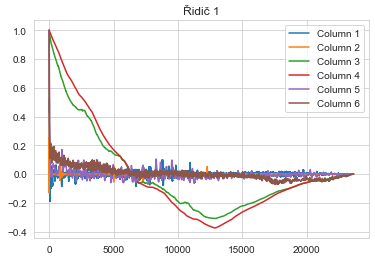

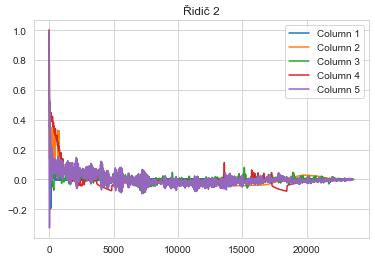

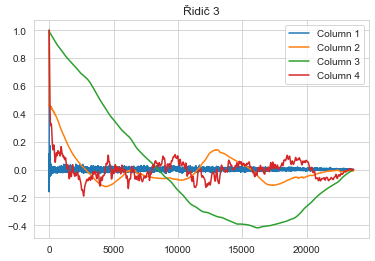

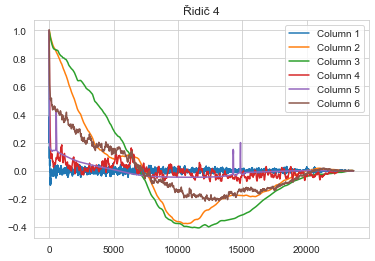

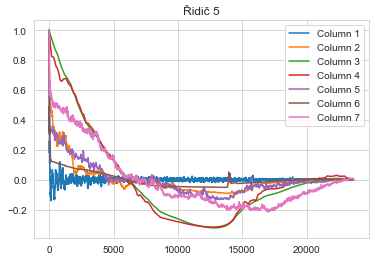

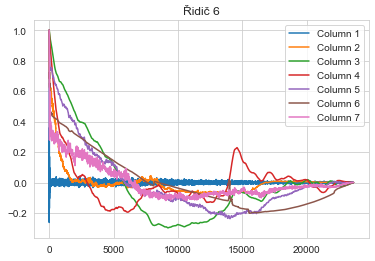

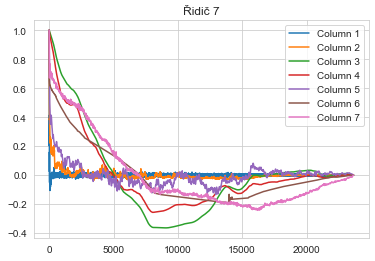

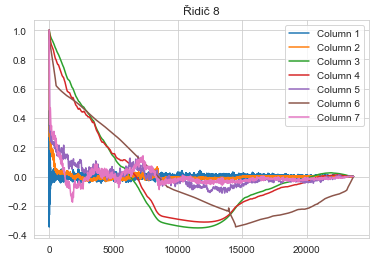

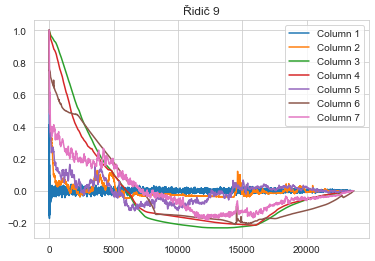

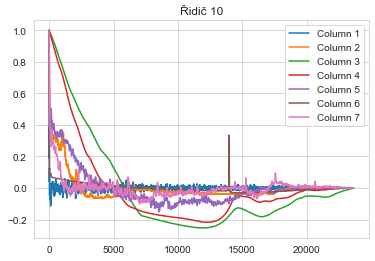

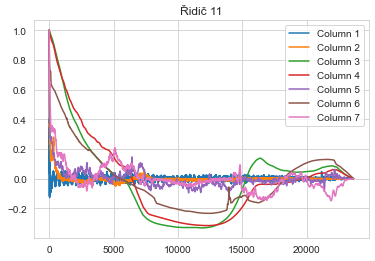

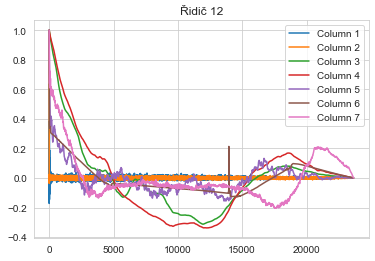

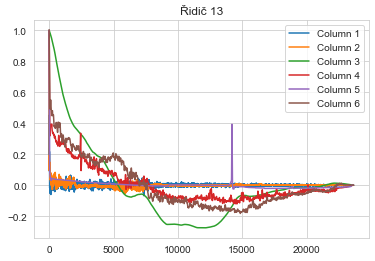

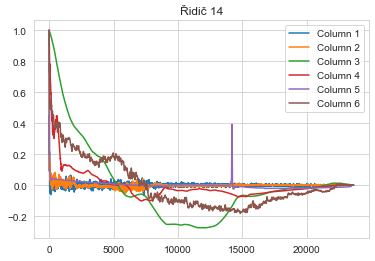

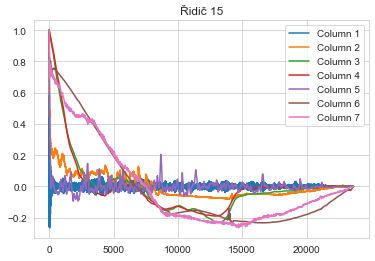

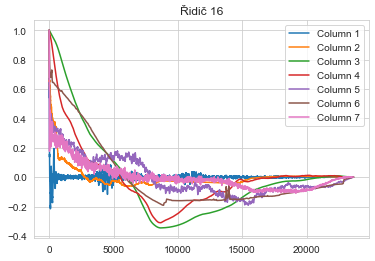

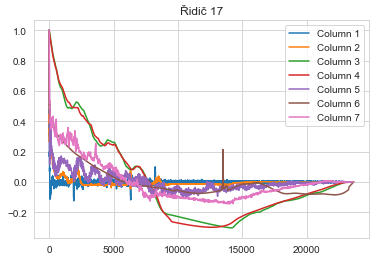

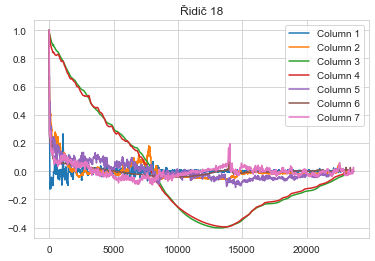

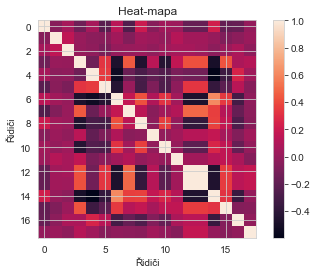

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import find_peaks, resample
from wfdb import rdsamp
from fractions import Fraction
from statsmodels.tsa.stattools import acf

class Signal:
    def __init__(self, signal, freq, time):
        self.signal = signal
        self.freq = freq
        self.time = time

signals = []
for i in range(1, 19):
    if i < 10:
        file_id = '0' + str(i)
    else:
        file_id = str(i)

    if i < 17:
        signal, fields = rdsamp('data/drive' + file_id)
    elif i == 17:
        signal, fields = rdsamp('data/drive17a')
    else:
        signal, fields = rdsamp('data/drive17b')

    signals.append(Signal(signal, fields['fs'], np.arange(0, len(signal) / fields['fs'], 1 / fields['fs'])))

def get_dominant_freq(signals):
    freqs = [s.freq for s in signals]
    dom_freq = max(set(freqs), key=freqs.count)
    return dom_freq, freqs.index(dom_freq)

dom_freq, dom_freq_idx = get_dominant_freq(signals)

def prepare_signals(signals, dom_freq):
    if dom_freq is None:
        raise ValueError("dom_freq cannot be None")
    
    for s in signals:
        if s.freq is None:
            raise ValueError(f"freq for signal {s} cannot be None")
        
        if not isinstance(s.freq, (int, float)):
            raise ValueError(f"freq for signal {s} must be a number, not {type(s.freq)}")
        
        if not isinstance(dom_freq, (int, float)):
            raise ValueError(f"dom_freq must be a number, not {type(dom_freq)}")
        
        resample_factor = s.freq / dom_freq
        s.signal = resample(s.signal, int(len(s.signal) * resample_factor))
        s.time = resample(s.time, int(len(s.time) * resample_factor))
        s.freq = dom_freq




prepare_signals(signals, dom_freq)

def get_peaks(signals):
    peaks = []
    for s in signals:
        peak_values = []
        for column in s.signal.T:
            peak, _ = find_peaks(column, height=0.8)
            if peak.size > 0:
                peak_values.append(s.time[peak][0])
        max_peak = max(peak_values) if peak_values else None
        peaks.append(max_peak)
    return peaks



peaks = get_peaks(signals)
main_peak = peaks[dom_freq_idx]

def adjust_signals(signals, peaks, main_peak):
    for s, p in zip(signals, peaks):
        s.time = s.time + main_peak - p

adjust_signals(signals, peaks, main_peak)

def get_shortest_signal(signals):
    lengths = [len(s.signal) for s in signals]
    min_len = min(lengths)
    return min_len

min_len = get_shortest_signal(signals)

def truncate_signals(signals, min_len):
    for s in signals:
        s.signal = s.signal[:min_len]
        s.time = s.time[:min_len]

truncate_signals(signals, min_len)

def compute_autocorr(signals):
    for i, s in enumerate(signals):
        for j, column in enumerate(s.signal.T):
            autocorr = acf(column, nlags=len(column)-1, fft=True)
            plt.figure(i+1)
            plt.plot(autocorr, label=f'Column {j+1}')
        plt.title(f'Řidič {i+1}')
        plt.legend()

compute_autocorr(signals)

def compute_correlation_coeff(signals):
    corr_coef = np.zeros((len(signals), len(signals)))
    for i, s1 in enumerate(signals):
        for j, s2 in enumerate(signals):
            for k in range(min(s1.signal.shape[1], s2.signal.shape[1])):
                corr_coef[i, j] = np.corrcoef(s1.signal[:, k], s2.signal[:, k])[0, 1]
    plt.figure()
    plt.imshow(corr_coef)
    plt.colorbar()
    plt.xlabel("Řidiči")
    plt.ylabel("Řidiči")
    plt.title("Heat-mapa")



compute_correlation_coeff(signals)

# 3. Klasifikace EMG signálů
### Zadání
Ve zdrojové databázi najdete celkem 17 měření EMG signálu. Signál je již filtrován a centralizován kolem podélné osy. EMG signály zachycují aktivitu svalů během jízdy. Pro všech 17 měření spočítejte integrované EMG (iEMG) pomocí vzorce 𝑖𝐸𝑀𝐺 = ∫0𝑡|𝑓(𝑡)| d𝑡 kde, t je doba záznamu, 𝑓(𝑡) je EMG signál a | | symbolizuje absolutní hodnotu. Dále detekujte oblasti, kde u jednotlivých signálů dochází k nárůstu a poklesu aktivity, a to pomocí okénkové varianty iEMG a derivace funkce. Velikost okénka zvolte tak, aby byly výsledky statisticky spolehlivé.



## Řešení

Successfully read data/drive01.
Failed to read record data/drive02.
Failed to read record data/drive03.
Failed to read record data/drive04.
Successfully read data/drive05.
Successfully read data/drive06.
Successfully read data/drive07.
Successfully read data/drive08.
Successfully read data/drive09.
Successfully read data/drive10.
Successfully read data/drive11.
Successfully read data/drive12.
Successfully read data/drive13.
Successfully read data/drive14.
Successfully read data/drive15.
Successfully read data/drive16.
File data/drive17 does not exist.
File data/drive18 does not exist.


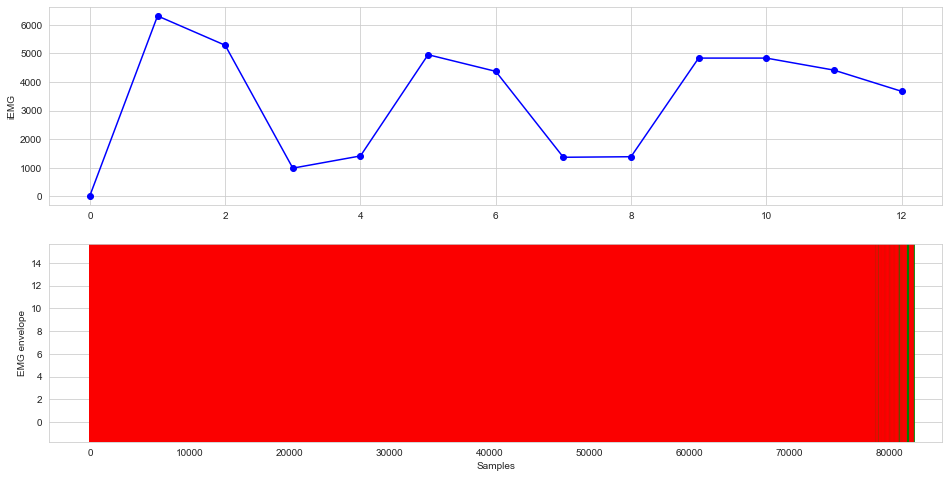

In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import scipy

# vytvoření prázdných seznamů pro uložení výsledků
iemg_values = []
onsets = []
offsets = []

import wfdb
import os



for i in range(1, 19):
    if i < 10:
        record_name = f"data/drive0{i}"
    else:
        record_name = f"data/drive{i}"

    # check if the file exists
    if not os.path.isfile(record_name + ".dat"):
        print(f"File {record_name} does not exist.")
        continue

    # read the record
    record = wfdb.rdrecord(record_name, channel_names=["EMG"])

    if record.p_signal is None:
        print(f"Failed to read record {record_name}.")
        continue
    else:
        print(f"Successfully read {record_name}.")

    # načtení záznamu
    record = wfdb.rdrecord(record_name, channel_names=["EMG"])
    emg_rectified = np.abs(record.p_signal)

    # filtraci signálu
    low_pass = 0.1
    low_pass = low_pass/(record.fs/2)

    b2, a2 = scipy.signal.butter(4, low_pass, btype='lowpass')
    emg_envelope = scipy.signal.filtfilt(b2, a2, emg_rectified[:,0])

    # výpočet iEMG
    T = 1/record.fs
    N = len(record.p_signal)
    t = np.linspace(0.0, T*N, N)
    integrated_emg_value = np.trapz(emg_envelope, t)
    iemg_values.append(integrated_emg_value)

    # detekce nárůstu a poklesu aktivity
    window_size = 0.5 # velikost okna v sekundách
    window_samples = int(window_size*record.fs)
    emg_derivative = np.diff(emg_envelope)
    for j in range(0, len(emg_derivative)-window_samples, window_samples):
        window = emg_derivative[j:j+window_samples]
        if np.mean(window) > 0:
            onsets.append(j)
        elif np.mean(window) < 0:
            offsets.append(j)

# vizualizace výsledků
plt.figure(figsize=(16,8))
plt.subplot(2,1,1)
plt.plot(iemg_values, 'bo-')
plt.ylabel('iEMG')
plt.subplot(2,1,2)
plt.plot(emg_envelope, 'k')
for onset in onsets:
    plt.axvline(onset, color='g', alpha=0.3)
for offset in offsets:
    plt.axvline(offset, color='r', alpha=0.3)
plt.ylabel('EMG envelope')
plt.xlabel('Samples')
plt.show()